In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

sns.set_style("whitegrid")

In [4]:
from google.colab import files
uploaded = files.upload()

Saving train_FD001.txt to train_FD001.txt
Saving RUL_FD001.txt to RUL_FD001.txt
Saving test_FD001.txt to test_FD001.txt


In [5]:
# Column names based on official CMAPSS documentation
index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = [f'sensor_{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

train_df = pd.read_csv('train_FD001.txt', sep=r'\s+', header=None, names=col_names)
test_df = pd.read_csv('test_FD001.txt', sep=r'\s+', header=None, names=col_names)
rul_df = pd.read_csv('RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'])

print(train_df.shape)
train_df.head()

(20631, 26)


,unit_number,time_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [6]:
# Max cycle per engine = when it failed
max_cycle = train_df.groupby('unit_number')['time_cycles'].max().reset_index()
max_cycle.columns = ['unit_number', 'max_cycle']

train_df = train_df.merge(max_cycle, on='unit_number', how='left')
train_df['RUL'] = train_df['max_cycle'] - train_df['time_cycles']
train_df.drop('max_cycle', axis=1, inplace=True)

# Clip RUL — engines behave normally until close to failure
RUL_CLIP = 125
train_df['RUL'] = train_df['RUL'].clip(upper=RUL_CLIP)

train_df[['unit_number', 'time_cycles', 'RUL']].head(10)

,unit_number,time_cycles,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125
5,1,6,125
6,1,7,125
7,1,8,125
8,1,9,125
9,1,10,125


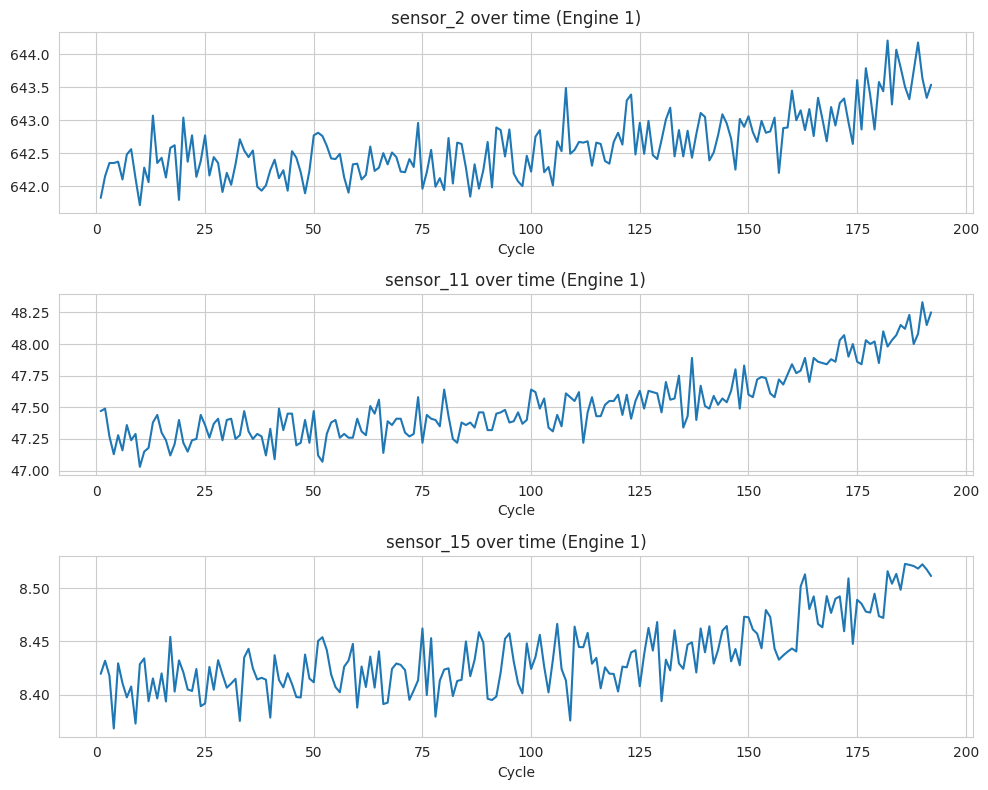

In [7]:
engine_1 = train_df[train_df['unit_number'] == 1]

fig, axes = plt.subplots(3, 1, figsize=(10, 8))
for ax, sensor in zip(axes, ['sensor_2', 'sensor_11', 'sensor_15']):
    ax.plot(engine_1['time_cycles'], engine_1[sensor])
    ax.set_title(f'{sensor} over time (Engine 1)')
    ax.set_xlabel('Cycle')
plt.tight_layout()
plt.savefig('sensor_trends_engine1.png', dpi=150)
plt.show()

In [8]:
std_per_sensor = train_df[sensor_names].std()
print(std_per_sensor.sort_values())

flat_sensors = std_per_sensor[std_per_sensor < 0.0001].index.tolist()
print("\nDropping flat sensors:", flat_sensors)

useful_sensors = [s for s in sensor_names if s not in flat_sensors]

sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.556432e-14
sensor_10    4.660829e-13
sensor_5     3.394700e-12
sensor_1     6.537152e-11
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64

Dropping flat sensors: ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


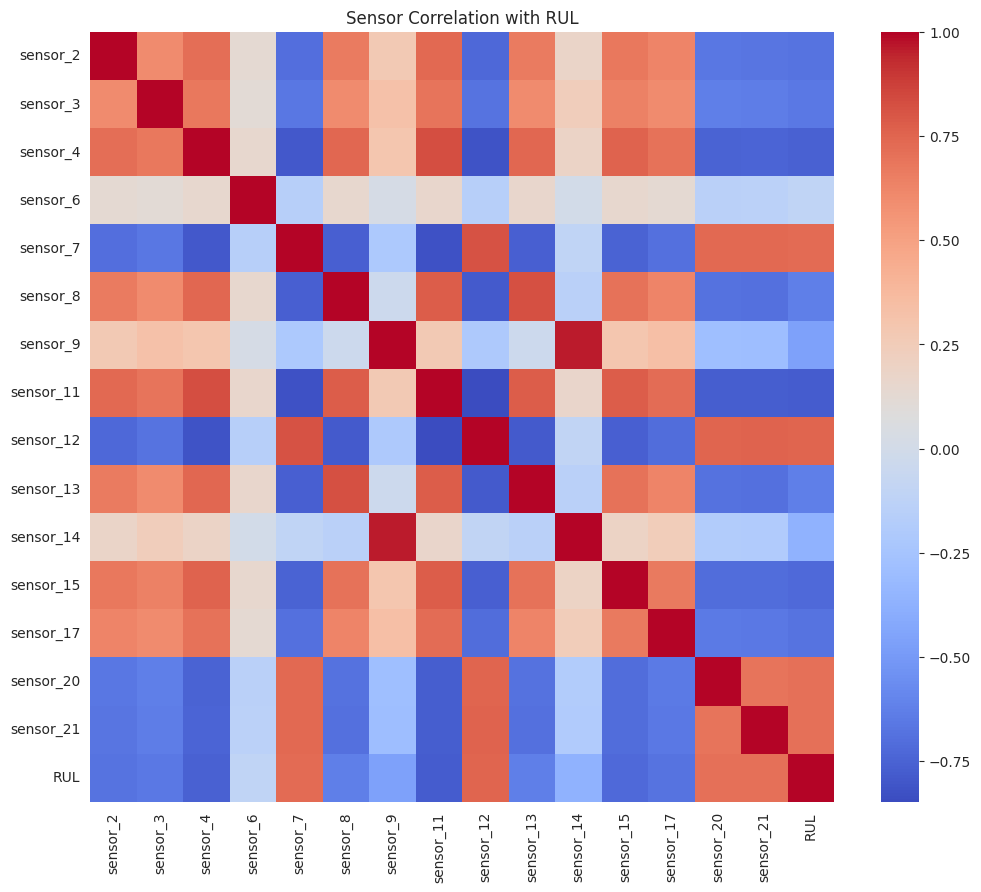

In [9]:
plt.figure(figsize=(12, 10))
sns.heatmap(train_df[useful_sensors + ['RUL']].corr(), cmap='coolwarm', annot=False)
plt.title('Sensor Correlation with RUL')
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [10]:
X = train_df[useful_sensors + setting_names]
y = train_df['RUL']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

print("Model trained successfully")

Model trained successfully


In [11]:
# Test set: take the LAST cycle per engine (that's what we predict RUL for)
test_last = test_df.groupby('unit_number').last().reset_index()
X_test = test_last[useful_sensors + setting_names]

preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(rul_df['RUL'], preds))
mae = mean_absolute_error(rul_df['RUL'], preds)
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

RMSE: 17.89
MAE: 13.05


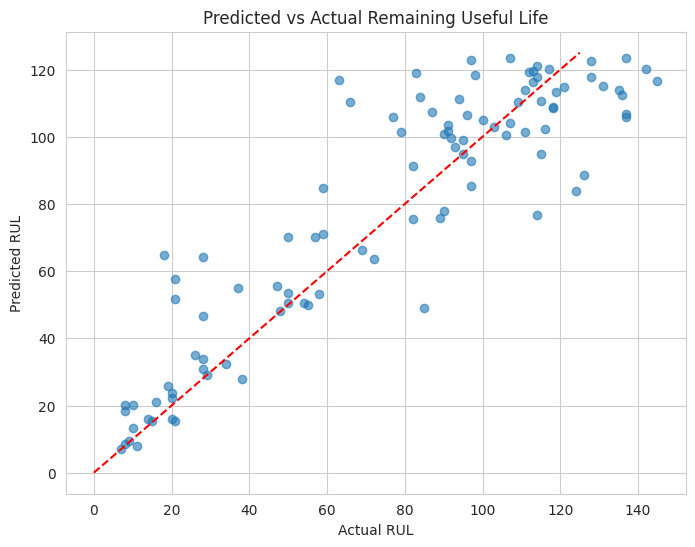

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(rul_df['RUL'], preds, alpha=0.6)
plt.plot([0, 125], [0, 125], 'r--')  # perfect prediction line
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title('Predicted vs Actual Remaining Useful Life')
plt.savefig('predicted_vs_actual.png', dpi=150)
plt.show()

In [13]:
window_size = 5

def add_rolling_features(df, sensors, window):
    df = df.sort_values(['unit_number', 'time_cycles'])
    for sensor in sensors:
        df[f'{sensor}_rollmean'] = df.groupby('unit_number')[sensor]\
            .transform(lambda x: x.rolling(window, min_periods=1).mean())
        df[f'{sensor}_rollstd'] = df.groupby('unit_number')[sensor]\
            .transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))
    return df

train_df = add_rolling_features(train_df, useful_sensors, window_size)
train_df.head()

,unit_number,time_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14_rollmean,sensor_14_rollstd,sensor_15_rollmean,sensor_15_rollstd,sensor_17_rollmean,sensor_17_rollstd,sensor_20_rollmean,sensor_20_rollstd,sensor_21_rollmean,sensor_21_rollstd
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.620000,0.000000,8.419500,0.000000,392.000000,0.000000,39.060000,0.000000,23.419000,0.000000
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8135.055000,5.041671,8.425650,0.008697,392.000000,0.000000,39.030000,0.042426,23.421300,0.003253
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8134.446667,3.717450,8.423033,0.007640,391.333333,1.154701,39.003333,0.055076,23.395600,0.044573
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8134.292500,3.050906,8.409325,0.028117,391.500000,1.000000,38.972500,0.076322,23.390175,0.037977
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8134.194000,2.651326,8.413340,0.025953,391.800000,1.095445,38.958000,0.073621,23.393020,0.033498


In [14]:
rolling_features = [f'{s}_rollmean' for s in useful_sensors] + [f'{s}_rollstd' for s in useful_sensors]
X = train_df[useful_sensors + setting_names + rolling_features]
y = train_df['RUL']

model_v2 = RandomForestRegressor(n_estimators=100, random_state=42)
model_v2.fit(X, y)
print("Model v2 trained with rolling features")

Model v2 trained with rolling features


In [15]:
test_df = add_rolling_features(test_df, useful_sensors, window_size)
test_last = test_df.groupby('unit_number').last().reset_index()
X_test = test_last[useful_sensors + setting_names + rolling_features]

preds_v2 = model_v2.predict(X_test)
rmse_v2 = np.sqrt(mean_squared_error(rul_df['RUL'], preds_v2))
mae_v2 = mean_absolute_error(rul_df['RUL'], preds_v2)
print(f"RMSE (with rolling features): {rmse_v2:.2f}")
print(f"MAE (with rolling features): {mae_v2:.2f}")

RMSE (with rolling features): 19.12
MAE (with rolling features): 13.94


In [16]:
ALERT_THRESHOLD = 30  # cycles remaining — below this, flag for maintenance

alert_df = test_last[['unit_number']].copy()
alert_df['predicted_RUL'] = preds_v2
alert_df['alert'] = alert_df['predicted_RUL'] < ALERT_THRESHOLD
alert_df['status'] = alert_df['alert'].map({True: '🔴 MAINTENANCE NEEDED', False: '🟢 OK'})

print(alert_df.sort_values('predicted_RUL').head(15))

    unit_number  predicted_RUL  alert                status
33           34           4.47   True  🔴 MAINTENANCE NEEDED
80           81           6.89   True  🔴 MAINTENANCE NEEDED
34           35           9.33   True  🔴 MAINTENANCE NEEDED
75           76          11.54   True  🔴 MAINTENANCE NEEDED
30           31          11.57   True  🔴 MAINTENANCE NEEDED
55           56          11.72   True  🔴 MAINTENANCE NEEDED
67           68          12.32   True  🔴 MAINTENANCE NEEDED
81           82          12.77   True  🔴 MAINTENANCE NEEDED
91           92          15.73   True  🔴 MAINTENANCE NEEDED
65           66          16.01   True  🔴 MAINTENANCE NEEDED
99          100          18.90   True  🔴 MAINTENANCE NEEDED
90           91          19.34   True  🔴 MAINTENANCE NEEDED
41           42          19.45   True  🔴 MAINTENANCE NEEDED
23           24          19.99   True  🔴 MAINTENANCE NEEDED
35           36          20.22   True  🔴 MAINTENANCE NEEDED


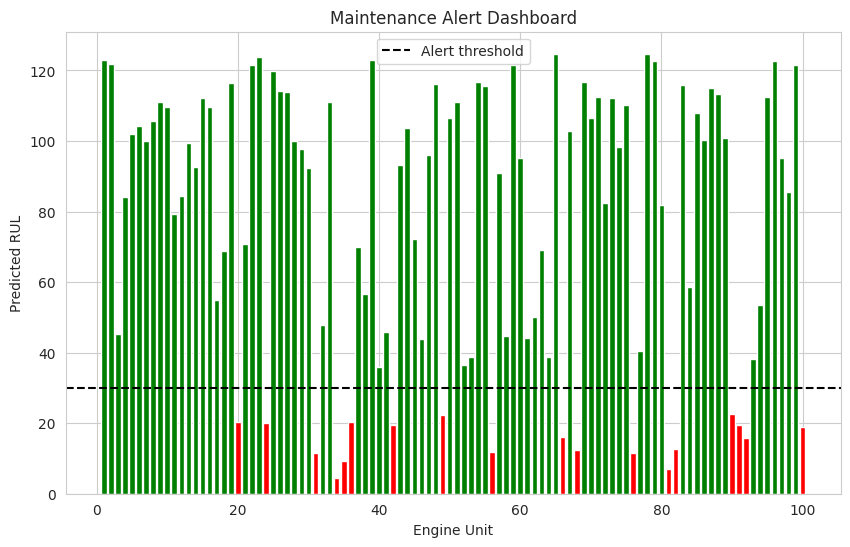

In [17]:
plt.figure(figsize=(10,6))
colors = alert_df['alert'].map({True: 'red', False: 'green'})
plt.bar(alert_df['unit_number'], alert_df['predicted_RUL'], color=colors)
plt.axhline(y=ALERT_THRESHOLD, color='black', linestyle='--', label='Alert threshold')
plt.xlabel('Engine Unit')
plt.ylabel('Predicted RUL')
plt.title('Maintenance Alert Dashboard')
plt.legend()
plt.savefig('maintenance_alerts.png', dpi=150)
plt.show()